In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import time
import os
import datetime
import math

In [2]:
dir_data = r"data\statistics_and_transformed"

In [3]:
ncdata = xr.open_dataset(os.path.join(dir_data,"Seasonal_daily_standard_anomaly.nc"))

In [15]:
ncdata

<xarray.Dataset> Size: 15GB
Dimensions:       (latitude: 281, longitude: 441, time: 30316)
Coordinates:
  * latitude      (latitude) float32 1kB 90.0 89.75 89.5 ... 20.5 20.25 20.0
  * longitude     (longitude) float32 2kB -150.0 -149.8 -149.5 ... -40.25 -40.0
  * time          (time) datetime64[ns] 243kB 1940-01-01 ... 2022-12-31
    season        <U3 12B ...
Data variables:
    daily_t2_min  (time, latitude, longitude) float32 15GB ...

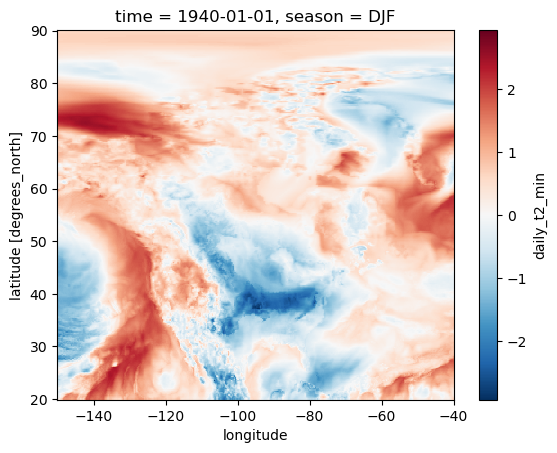

In [19]:
ncdata["daily_t2_min"].sel(time="1940-01-01").plot()

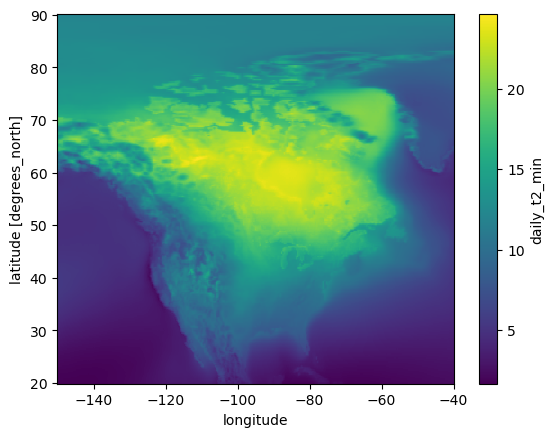

In [8]:
(ncdata["daily_t2_min"].sel(season = "SON") - ncdata["daily_t2_min"].sel(season = "DJF")).plot()

In [20]:
ncdata = xr.open_dataset(os.path.join(dir_data,"Rolling_daily_mean.nc"))

ncdata

<xarray.Dataset> Size: 181MB
Dimensions:       (latitude: 281, longitude: 441, dayofyear: 366)
Coordinates:
  * latitude      (latitude) float32 1kB 90.0 89.75 89.5 ... 20.5 20.25 20.0
  * longitude     (longitude) float32 2kB -150.0 -149.8 -149.5 ... -40.25 -40.0
  * dayofyear     (dayofyear) int64 3kB 1 2 3 4 5 6 ... 361 362 363 364 365 366
Data variables:
    daily_t2_min  (dayofyear, latitude, longitude) float32 181MB ...

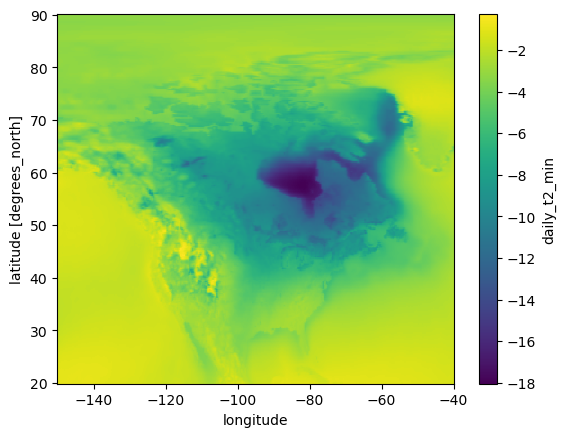

In [37]:
(ncdata["daily_t2_min"].sel(dayofyear=10)-ncdata["daily_t2_min"].sel(dayofyear=330)).plot()

0
1
2
3
4
5


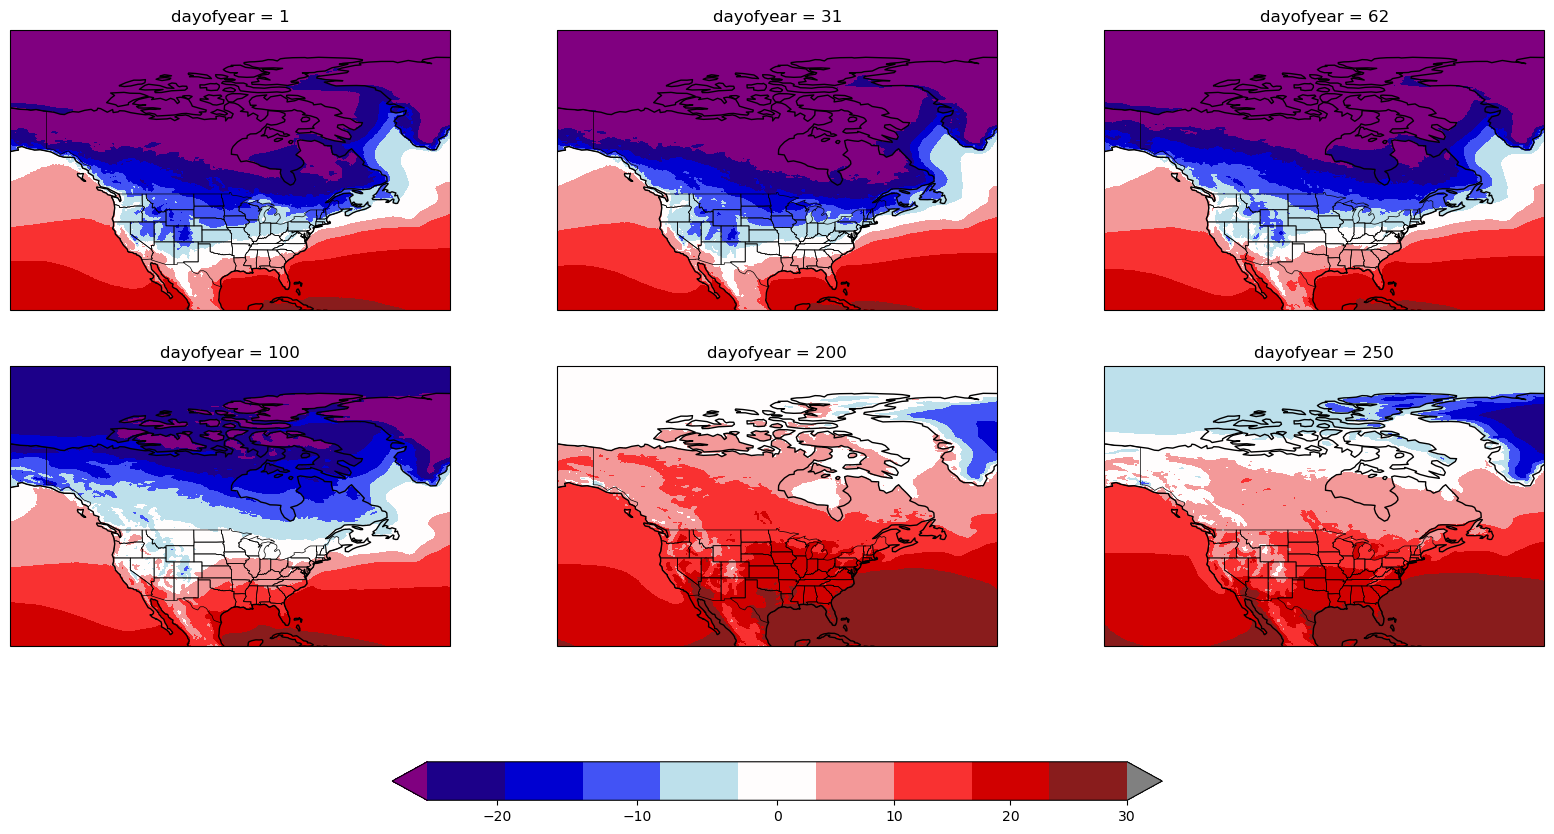

In [47]:
#Explorer
cmap_standard = matplotlib.colors.LinearSegmentedColormap.from_list("", ["purple","darkblue","blue","lightblue","white","lightcoral","red","darkred","gray"])
z_standard = [-25,-20,-15,-10,-5,0,5,10,20,30]
norm_standard = TwoSlopeNorm(vmin=np.min(z_standard), vcenter=0, vmax=np.max(z_standard))
fig, axes = plt.subplots(nrows=2, ncols=3,
                            subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(20,10))

days = [1,31,62,100,200,250]
axes = axes.flatten()
j=0
for i in days:
    print(j)
    p=(ncdata["daily_t2_min"]-273.15).sel(dayofyear=i).plot(ax=axes[j],cmap=cmap_standard,norm=norm_standard,levels=z_standard,extend="both", transform=ccrs.PlateCarree(),add_colorbar=False)
    j=j+1
    #plt.colorbar(p).remove() 
    #fig.colorbar(p, ax=axes[i]).set_label(label='Temp. difference [\u00b0C]', size=14)
#ax.coastlines()
#ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
#tg90_two.plot(x="lon", y="lat", col="time", col_wrap=1)
#plt.show()

for n, ax in enumerate(axes):
    ax.coastlines()
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
    #ax.set_extent([-170, -35, 15, 85])
fig.colorbar(p, ax=axes, orientation='horizontal', fraction=.05)
#plt.savefig(os.path.join(save_path, 'temp_stdev.png'))
#plt.close()
plt.show()

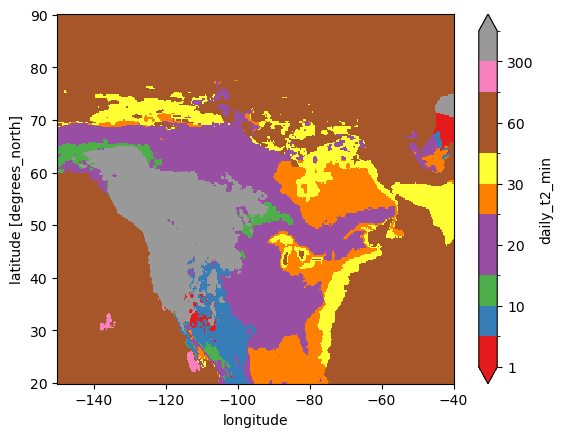

In [65]:
(ncdata["daily_t2_min"]).argmin(dim='dayofyear').plot(cmap="Set1",levels=[1,5,10,15,20,25,30,35,60,90,300,365],extend='both')

In [158]:
from distributed import Client,LocalCluster

cluster = LocalCluster()         
client = cluster.get_client()
print(cluster.get_client)

PARAMETERS = {
    "dir_nc_data": r"C:\Users\ls2236\Projects\BIG\ERA5\arco-era5\data\daily",
    "dir_to_save": r"C:\Users\ls2236\Projects\CAO_TRACKER\data\statistics_and_transformed",
    "nc_variable": "daily_t2_min"
}

era5_data = xr.open_mfdataset(os.path.join(PARAMETERS["dir_nc_data"],"*.nc"))
#Select variable
t2min_raw = era5_data[PARAMETERS["nc_variable"]]




c:\Users\ls2236\AppData\Local\anaconda3\envs\arco\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52717 instead
  warnings.warn(


<bound method Cluster.get_client of LocalCluster(b37ebff7, 'tcp://127.0.0.1:52718', workers=6, threads=24, memory=63.25 GiB)>


In [247]:
daily_t2_min = np.zeros([366,281,441])
lon = t2min_raw.longitude.values
lat = t2min_raw.latitude.values
time =range(1,367,1)

da = xr.DataArray(
    data=daily_t2_min,
    dims=[ "dayofyear", "latitude","longitude",],
    coords=dict(
        dayofyear=time,
        latitude=(["latitude"], lat),
        longitude=(["longitude"], lon)
    ),
    attrs=dict(
        long_name="2 metre temperature",
        short_name="t2m",
        unit="K"
    ))


da = xr.Dataset(
    data_vars=dict(
        daily_t2_min=(["dayofyear", "latitude","longitude"],daily_t2_min)
    ),
    #dims=[ "dayofyear", "latitude","longitude",],
    coords=dict(
        dayofyear=time,
        latitude=(["latitude"], lat),
        longitude=(["longitude"], lon)
    ),
    attrs=dict(
        long_name="2 metre temperature",
        short_name="t2m",
        unit="K"
    ))




In [249]:
window=15

for doy in range(1, 3,1):
    #doys = [365 + doy if doy <= 0 else doy for doy in np.arange(doy - window, doy + window + 1)]
    doys=np.arange(doy - window, doy + window + 1)
    doys=list(map(lambda x: 366+x if (x<=0) else x, doys))
    doys=list(map(lambda x: x-366 if (x>366) else x, doys))
    print(doys)
    tmp = t2min_raw.where(t2min_raw.time.dt.dayofyear.isin(doys)).std(dim="time")
    da.loc[dict(dayofyear=doy)] = tmp

#ds_out = xr.concat(ds_clima, dim='doy').load()

[np.int64(352), np.int64(353), np.int64(354), np.int64(355), np.int64(356), np.int64(357), np.int64(358), np.int64(359), np.int64(360), np.int64(361), np.int64(362), np.int64(363), np.int64(364), np.int64(365), np.int64(366), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
[np.int64(353), np.int64(354), np.int64(355), np.int64(356), np.int64(357), np.int64(358), np.int64(359), np.int64(360), np.int64(361), np.int64(362), np.int64(363), np.int64(364), np.int64(365), np.int64(366), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]


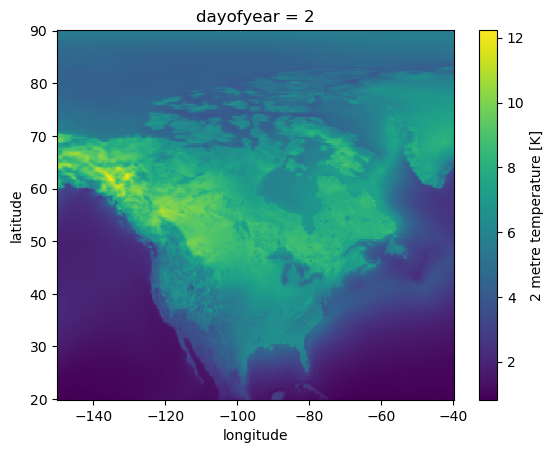

In [252]:
da.sel(dayofyear=2).plot()

In [ ]:
#da.loc[dict(dayofyear=2)]
doy=365
doys = [365 + doy if doy <= 0 else doy for doy in np.arange(doy - window, doy + window + 1)]
list(filter(lambda x: x<367, doys))

In [229]:
a=list(filter(lambda x: x<1, doys))
b=list(filter(lambda x: x>367, doys))
b=list(map(lambda x: x-366+1, b))
c=list(filter(lambda x: x <= 366, doys))

In [ ]:
#ds_clima = xr.DataArray(ncdata,coords={"latitude": ncdata["latitude"].values,"longitude": ncdata["longitude"].values},dims=['latitude','longitude'])
ds_clima = xr.Dataset(
    {
        "temperature_c": (
            ("latitude", "longitude","dayofyear"),
            np.zeros(369135522)),
    },
    coords={"latitude": ncdata.latitude.values, "longitude":ncdata.longitude.values,"dayofyear": range(1,367,1)},
)
ds_clima

In [ ]:
ds_clima = xr.DataArray(
    np.zeros(369135522),
    coords = [np.array([2287,441,366])],
    dims = ["longitude","latitude","dayofyear"]
)

In [96]:
da = xr.DataArray(
    np.random.rand(4),
    coords=[np.array([358, 359, 0, 1])],
    dims="lon",
)

In [106]:
np.ones([3,4,5])

array([[[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]],

       [[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]],

       [[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]])

In [134]:
temperature = np.zeros([4, 4, 4])
lon = [-99.83, -99.32, -99.79, -99.23]
lat = [42.25, 42.21, 42.63, 42.59]
time =[0,1,2,3]

da = xr.Dataset(
    data_vars=dict(
        daily_t2_min=(["longitude","latitude","dayofyear"])
    ),
    data=temperature,
    dims=["longitude", "latitude", "dayofyear"],
    coords=dict(
        lon=(["longitude"], lon),
        lat=(["latitude"], lat),
        dayofyear=time
    ),
    attrs=dict(
        description="Ambient temperature.",
        units="degC",
    ))

In [167]:
ncdata

<xarray.Dataset> Size: 181MB
Dimensions:       (latitude: 281, longitude: 441, dayofyear: 366)
Coordinates:
  * latitude      (latitude) float32 1kB 90.0 89.75 89.5 ... 20.5 20.25 20.0
  * longitude     (longitude) float32 2kB -150.0 -149.8 -149.5 ... -40.25 -40.0
  * dayofyear     (dayofyear) int64 3kB 1 2 3 4 5 6 ... 361 362 363 364 365 366
Data variables:
    daily_t2_min  (dayofyear, latitude, longitude) float32 181MB 245.0 ... 295.6

In [149]:
np.size(ncdata["daily_t2_min"].longitude.values)

441

In [18]:
rolling = xr.open_dataset(os.path.join(dir_data,"Rolling_daily_stdev.nc"))
seasonal = xr.open_dataset(os.path.join(dir_data,"Seasonal_daily_stdev.nc"))

In [25]:
rolling

<xarray.Dataset> Size: 363MB
Dimensions:       (dayofyear: 366, latitude: 281, longitude: 441)
Coordinates:
  * dayofyear     (dayofyear) int64 3kB 1 2 3 4 5 6 ... 361 362 363 364 365 366
  * latitude      (latitude) float32 1kB 90.0 89.75 89.5 ... 20.5 20.25 20.0
  * longitude     (longitude) float32 2kB -150.0 -149.8 -149.5 ... -40.25 -40.0
Data variables:
    daily_t2_min  (dayofyear, latitude, longitude) float64 363MB ...
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    unit:        K

In [26]:
seasonal

<xarray.Dataset> Size: 499kB
Dimensions:       (latitude: 281, longitude: 441)
Coordinates:
  * latitude      (latitude) float32 1kB 90.0 89.75 89.5 ... 20.5 20.25 20.0
  * longitude     (longitude) float32 2kB -150.0 -149.8 -149.5 ... -40.25 -40.0
    season        <U3 12B 'DJF'
Data variables:
    daily_t2_min  (latitude, longitude) float32 496kB ...

In [21]:
seasonal = seasonal.sel(season="DJF")

In [48]:
bins = pd.IntervalIndex.from_tuples([(0, 2), (2, 4), (4, 6),(6,8),(8,10),(10,20)])
pd.cut(np.array([1, 1.5 , 7, 5, 4, 6, 3, 5.75]), bins)

[(0, 2], (0, 2], (6, 8], (4, 6], (2, 4], (4, 6], (2, 4], (4, 6]]
Categories (6, interval[int64, right]): [(0, 2] < (2, 4] < (4, 6] < (6, 8] < (8, 10] < (10, 20]]

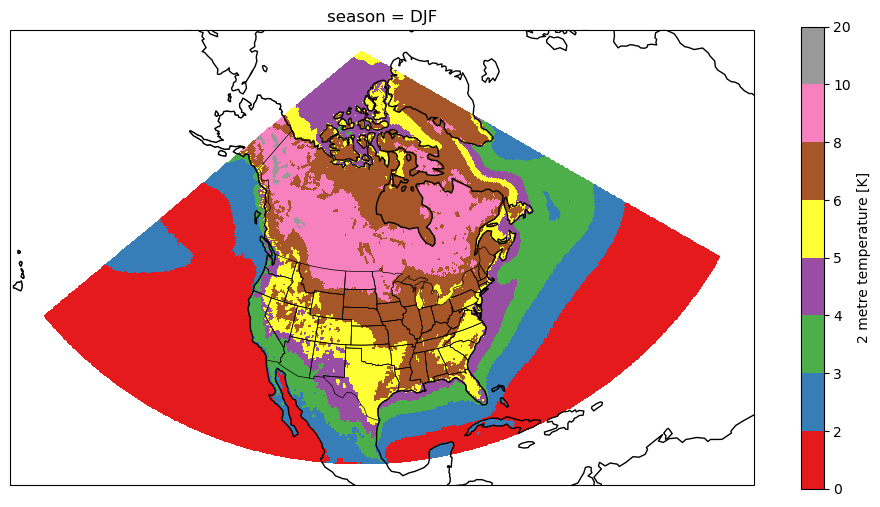

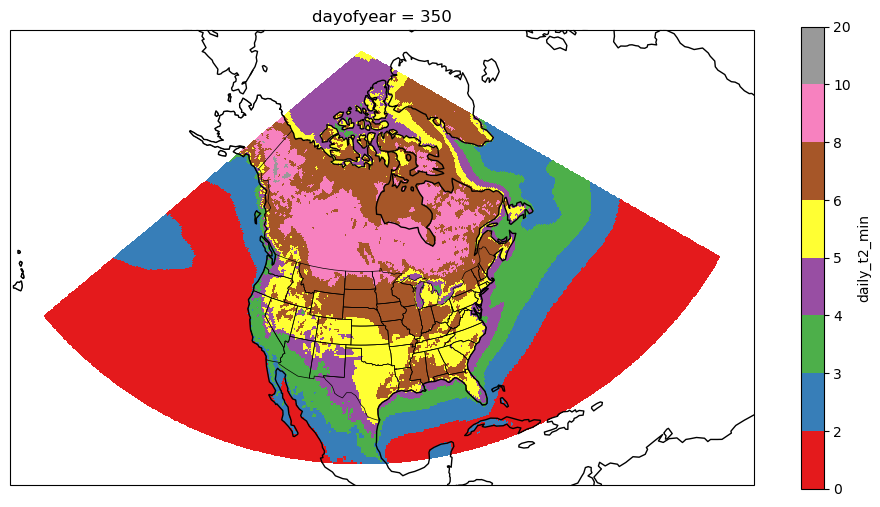

In [70]:
levels = [0,2,3,4,5,6,8,10,20]



plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-100))
seasonal["daily_t2_min"].plot(cmap="Set1",levels=levels,transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
plt.show()


plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-100))
rolling["daily_t2_min"].sel(dayofyear=350).plot(ax=ax,cmap="Set1",levels=levels,transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
plt.show()

In [236]:
#result = xr.apply_ufunc(pd.cut, rolling["daily_t2_min"].sel(dayofyear=350), kwargs={'bins': bins},vectorize=True)
bins = [0, 2, 3, 4, 5, 6, 8, 10, 20]
data=rolling["daily_t2_min"].sel(dayofyear=350)

def digitize_func(array):
    return np.digitize(array, bins) - 1  # -1 to make it zero-indexed

binned_data = xr.apply_ufunc(
    digitize_func,
    data,
    input_core_dims=[["latitude", "longitude"]],
    output_core_dims=[["latitude", "longitude"]],  # Specify output dimensions
    vectorize=True,
    #output_dtypes=[int]  # Ensure the output is integer type
)

labeled_array, num_features = ndimage.label(binned_data.values)
# Create a labeled DataArray
labeled_data = xr.DataArray(labeled_array, dims=["latitude", "longitude"],
                             coords={"latitude": data.latitude, "longitude": data.longitude})

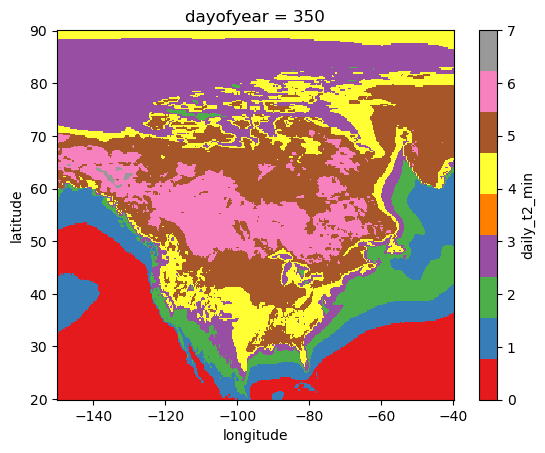

In [237]:
binned_data.plot(cmap="Set1")


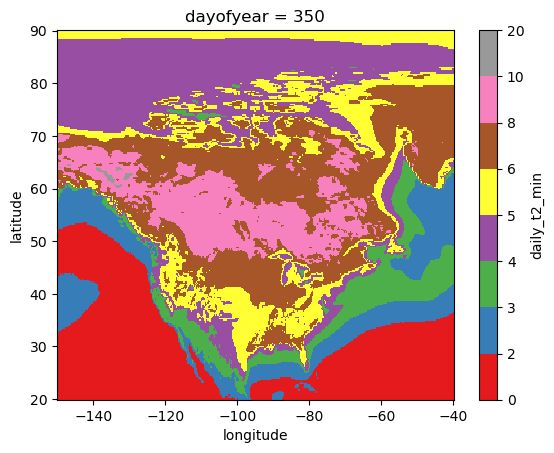

In [234]:
rolling["daily_t2_min"].sel(dayofyear=350).plot(cmap="Set1",levels=bins)

In [224]:
np.unique(labeled_array,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32),
 array([23357, 99029,  1390,     3,     1,    50,    13,     2,    74,
            2]))

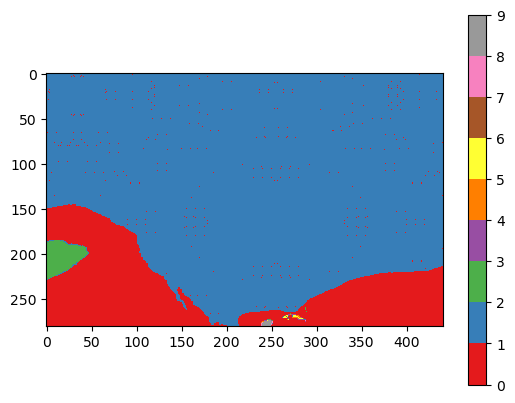

In [228]:
plt.imshow(labeled_array,cmap="Set1")
plt.colorbar()
plt.show()

In [204]:
np.unique(binned_data.values)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [89]:
def create_dataarray(nlat, nlon, ntime=None, seed=1000):

    np.random.seed(seed)
    
    lat = np.linspace(-90, 90, nlat, endpoint=True)
    lat = xr.DataArray(lat, dims=('lat',), coords={'lat': lat}, attrs={'units': 'degree_north', 'name': 'Latitude'})
    
    lon = np.linspace(-180, 180, nlon+1, endpoint=True)[1:]
    lon = xr.DataArray(lon, dims=('lon',), coords={'lon': lon}, attrs={'units': 'degree_east', 'name': 'Longitude'})

    if ntime is not None:
        time = pd.date_range(start='2000-01-01', freq='D', periods=ntime)
        time = xr.DataArray(time, dims=('time',))
        return xr.DataArray(
            np.random.random([ntime, nlat, nlon]), 
            dims=('time', 'lat', 'lon'),
            coords={'time': time, 'lat': lat, 'lon': lon},
            attrs={'name': 'random'}
        )

    return xr.DataArray(
        np.random.random([nlat, nlon]), 
        dims=('lat', 'lon'),
        coords={'lat': lat, 'lon': lon},
        attrs={'name': 'random'}
    )

In [94]:
def limit(value, max_value=0.5):
    return max_value if max_value < value else value

In [97]:
small_da = create_dataarray(2, 5)
small_da

<xarray.DataArray (lat: 2, lon: 5)> Size: 80B
array([[0.65358959, 0.11500694, 0.95028286, 0.4821914 , 0.87247454],
       [0.21233268, 0.04070962, 0.39719446, 0.2331322 , 0.84174072]])
Coordinates:
  * lat      (lat) float64 16B -90.0 90.0
  * lon      (lon) float64 40B -108.0 -36.0 36.0 108.0 180.0
Attributes:
    name:     random

In [80]:
rolling.sel(dayofyear=350).groupby_bins(group="daily_t2_min",bins=bins,labels=["2", "4","6","8","10","12+"])

<DatasetGroupBy, grouped over 1 grouper(s), 6 groups in total:
    'daily_t2_min_bins': 6 groups with labels (0,, 2], (2,, 4], ..., (10,, 20]>

In [75]:
from scipy import ndimage

xr.apply_ufunc(sp.ndimage.label, arr, input_core_dims=[['x']], output_core_dims=[['x']])

labeled_slice, num_features = ndimage.label(rolling.sel(dayofyear=350).groupby_bins(group="daily_t2_min",bins=bins).values)
plt.imshow(labeled_slice)

AttributeError: 'DatasetGroupBy' object has no attribute 'values'

In [ ]:
labeled_slice=labeled_slice*ndimage.binary_fill_holes(labeled_slice)

In [44]:
#anomalies
anom_seas = xr.open_dataset(os.path.join(dir_data,"Seasonal_daily_standard_anomaly.nc"))
anom_roll =xr.open_dataset(os.path.join(dir_data,"Rolling_daily_standard_anomaly.nc"))
ts_seas = anom_seas["daily_t2_min"].sel(latitude=42,longitude=-76)
ts_roll = anom_roll["daily_t2_min"].sel(latitude=42,longitude=-76)

In [48]:
date_i = '2011-12-01'
date_f = '2012-02-28'

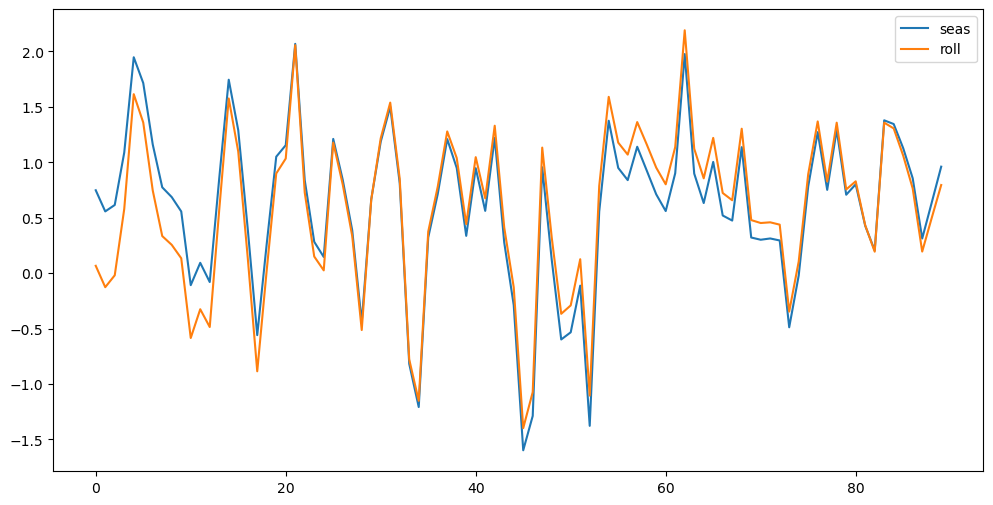

In [49]:
fig,ax=plt.subplots(figsize=(12,6))
plt.plot(ts_seas.sel(time = slice(date_i,date_f)).values,label='seas')
plt.plot(ts_roll.sel(time = slice(date_i,date_f)).values,label='roll')
legend = ax.legend(loc='best')
plt.show()

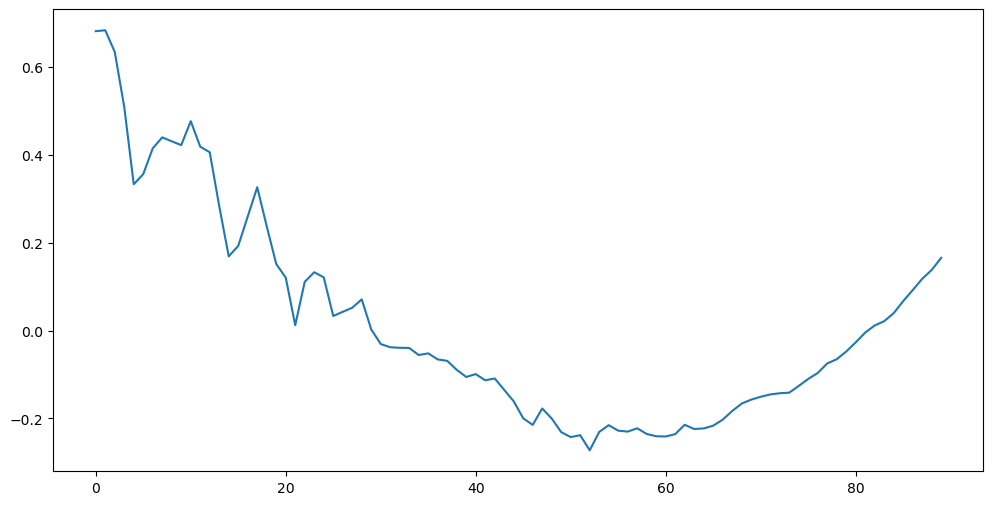

In [50]:
fig,ax=plt.subplots(figsize=(12,6))
plt.plot(ts_seas.sel(time = slice(date_i,date_f))-ts_roll.sel(time = slice(date_i,date_f)).values,label='seas')
plt.show()